# Convolutional Neural Networks (CNN)



In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [5]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images shape:", X_train.shape)
print("Testing images shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images shape: (60000, 28, 28)
Testing images shape: (10000, 28, 28)


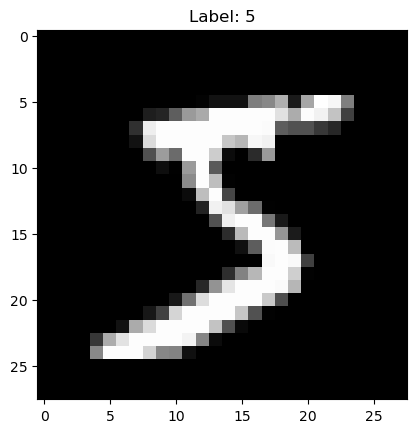

In [6]:
plt.imshow(X_train[0], cmap='gray')
plt.title("Label: {}".format(y_train[0]))
plt.show()

In [7]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)
# In the MNIST dataset, each pixel value represents the intensity of a grayscale pixel.
# These pixel values range from **0 to 255**.

# - 0 represents **black**
# - 255 represents **white**
# - Values in between represent different shades of gray
# in short we are doing normalization
X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
# imported model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [9]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

C:\Users\Shikshya\anaconda3\envs\project\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
# training the model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9494 - loss: 0.1676 - val_accuracy: 0.9848 - val_loss: 0.0508
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9850 - loss: 0.0488 - val_accuracy: 0.9870 - val_loss: 0.0457
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9891 - loss: 0.0339 - val_accuracy: 0.9888 - val_loss: 0.0401
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9927 - loss: 0.0240 - val_accuracy: 0.9918 - val_loss: 0.0312
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9931 - loss: 0.0204 - val_accuracy: 0.9885 - val_loss: 0.0409


In [13]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9912 - loss: 0.0283
Test accuracy: 0.9911999702453613


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


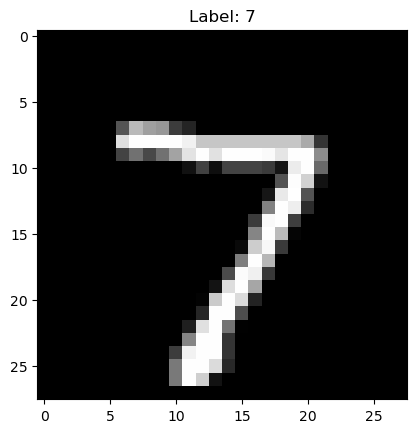

Predicted digit: 7


In [14]:
prediction = model.predict(X_test[:1])

plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title("Label: {}".format(y_test[0]))
plt.show()

print("Predicted digit:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


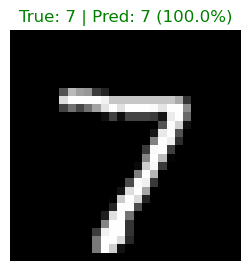

Image 7 probability breakdown:
  0: 0.0000  
  1: 0.0000  
  2: 0.0000  
  3: 0.0002  
  4: 0.0000  
  5: 0.0000  
  6: 0.0000  
  7: 0.9998  ███████████████████ ← predicted
  8: 0.0000  
  9: 0.0000  


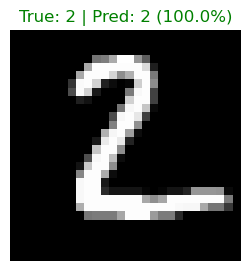

Image 2 probability breakdown:
  0: 0.0000  
  1: 0.0000  
  2: 0.9998  ███████████████████ ← predicted
  3: 0.0000  
  4: 0.0000  
  5: 0.0000  
  6: 0.0000  
  7: 0.0000  
  8: 0.0002  
  9: 0.0000  


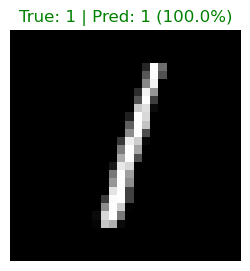

Image 1 probability breakdown:
  0: 0.0000  
  1: 0.9998  ███████████████████ ← predicted
  2: 0.0000  
  3: 0.0000  
  4: 0.0000  
  5: 0.0000  
  6: 0.0000  
  7: 0.0001  
  8: 0.0000  
  9: 0.0000  


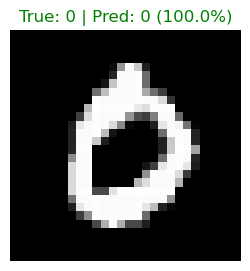

Image 0 probability breakdown:
  0: 0.9998  ███████████████████ ← predicted
  1: 0.0000  
  2: 0.0000  
  3: 0.0000  
  4: 0.0000  
  5: 0.0000  
  6: 0.0001  
  7: 0.0000  
  8: 0.0001  
  9: 0.0000  


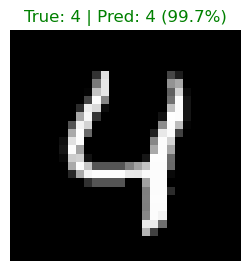

Image 4 probability breakdown:
  0: 0.0000  
  1: 0.0000  
  2: 0.0000  
  3: 0.0000  
  4: 0.9965  ███████████████████ ← predicted
  5: 0.0000  
  6: 0.0000  
  7: 0.0000  
  8: 0.0000  
  9: 0.0035  


In [36]:
num_images = 5
predictions = model.predict(X_test[:num_images])

for i in range(num_images):
    predicted_digit = np.argmax(predictions[i])
    confidence= np.max(predictions[i]) * 100
    true_label= y_test[i]
    is_correct= predicted_digit == true_label

    color = 'green' if is_correct else 'red'
    plt.figure(figsize=(3, 3))
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {true_label} | Pred: {predicted_digit} ({confidence:.1f}%)", color=color)
    plt.axis('off')
    plt.show()

    print(f"Image {predicted_digit} probability breakdown:")
    for digit, prob in enumerate(predictions[i]):
        bar    = '█' * int(prob * 20)
        marker = ' ← predicted' if digit == predicted_digit else ''
        print(f"  {digit}: {prob:.4f}  {bar}{marker}")
